In [1]:
# 1. Downgrade PyTorch to a highly stable version for Mamba on Kaggle T4
!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu124

# 2. Install specific versions of Mamba dependencies
!pip install causal-conv1d==1.4.0
!pip install mamba-ssm==2.2.2

# 3. Your existing MONAI setup
!pip install -q "monai[nibabel, tqdm]" einops torchinfo

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.1/797.1 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 9.7 MB/s eta 0:00:000:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 93.5 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 80.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 50.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 MB 5.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.4/128

In [2]:
import os
os.environ["NVCC_APPEND_FLAGS"] = "-std=c++17 -DCCCL_IGNORE_DEPRECATED_CPP_DIALECT"
import glob
import torch
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, Spacingd, NormalizeIntensityd,
    RandCropByPosNegLabeld, EnsureTyped, MapTransform
)
from monai.data import Dataset, DataLoader

# 1. Define the path to your BraTS dataset on Kaggle
# (Update this path if your Kaggle dataset is named differently)

data_dir="/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

# 2. Collect all patient folders
patient_folders = sorted(glob.glob(os.path.join(data_dir, "*[0-9]*")))

# 3. Create a list of dictionaries containing paths to the 4 MRI modalities and the segmentation mask
data_dicts =[]
for patient_dir in patient_folders:
    patient_id = os.path.basename(patient_dir)
    # Note: Kaggle BraTS datasets might use.nii or.nii.gz. Change the extension here if needed!
    data_dicts.append({
        "image": [
            os.path.join(patient_dir, f"{patient_id}_t1.nii"),
            os.path.join(patient_dir, f"{patient_id}_t1ce.nii"),
            os.path.join(patient_dir, f"{patient_id}_t2.nii"),
            os.path.join(patient_dir, f"{patient_id}_flair.nii")
        ],
        "label": os.path.join(patient_dir, f"{patient_id}_seg.nii")
    })

# Split into 80% train and 20% validation
train_files, val_files = data_dicts[:int(len(data_dicts)*0.8)], data_dicts[int(len(data_dicts)*0.8):]

# 4. Custom Transform to convert BraTS labels into 3 clinical channels
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result =[]
            # TC (Tumor Core): labels 1 (NCR/NET) + 4 (ET)
            result.append(torch.logical_or(d[key] == 1, d[key] == 4))
            # WT (Whole Tumor): labels 1 + 2 (Edema) + 4
            result.append(torch.logical_or(torch.logical_or(d[key] == 1, d[key] == 4), d[key] == 2))
            # ET (Enhancing Tumor): label 4
            result.append(d[key] == 4)
            d[key] = torch.stack(result, axis=0).float()
        return d

# 5. Define the MONAI Transforms for 3D Patch extraction
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image"]),
    ConvertToMultiChannelBasedOnBratsClassesd(keys=["label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    # RandCropByPosNegLabeld ensures we don't just sample empty background space
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=1,
        neg=1,
        num_samples=1,
        image_key="image",
        image_threshold=0,
    ),
    EnsureTyped(keys=["image", "label"]),
])

# 6. Create Dataset and DataLoader
# A batch size of 2 to 4 is safe for 3D patches across 2x T4 GPUs
train_ds = Dataset(data=train_files, transform=train_transforms)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)

print(f"Training samples loaded: {len(train_ds)}")

# Test a single batch to verify our tensor shapes are correct for Mamba
batch = next(iter(train_loader))
print(f"Image Batch Shape: {batch['image'].shape}") 
print(f"Label Batch Shape: {batch['label'].shape}")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-30 09:03:28.432965: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777539808.649605      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777539808.710873      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777539809.219702      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777539809.219737      57 computation_placer.cc:1

Training samples loaded: 295


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Image Batch Shape: torch.Size([4, 4, 96, 96, 96])
Label Batch Shape: torch.Size([4, 3, 96, 96, 96])


In [3]:
import transformers

# 1. Monkey-patch the missing classes back into transformers.generation
try:
    from transformers.generation import GenerateDecoderOnlyOutput
    transformers.generation.GreedySearchDecoderOnlyOutput = GenerateDecoderOnlyOutput
    transformers.generation.SampleDecoderOnlyOutput = GenerateDecoderOnlyOutput
except ImportError:
    pass

import torch
import torch.nn as nn
from monai.networks.blocks import UnetResBlock, UnetUpBlock, UnetOutBlock

# 2. Now it is safe to import Mamba
from mamba_ssm.modules.mamba_simple import Mamba

# ... [The rest of your VisionMamba3DBlock code follows below] ...



# 1. Define the 3D Vision Mamba Bottleneck Block
class VisionMamba3DBlock(nn.Module):
    def __init__(self, dim, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.dim = dim
        self.norm = nn.LayerNorm(dim)
        self.mamba = Mamba(
            d_model=dim,
            d_state=d_state,
            d_conv=d_conv,
            expand=expand
        )
    
    def forward(self, x):
        B, C, D, H, W = x.shape
        
        # Flatten the 3D spatial dimensions into a 1D sequence (B, L, C)
        x_flat = x.view(B, C, -1).permute(0, 2, 1)
        
        # Apply LayerNorm and the Mamba Selective Scan
        x_norm = self.norm(x_flat)
        x_mamba = self.mamba(x_norm)
        
        # Add residual skip connection and reshape back into a 3D volumetric tensor
        out_flat = x_mamba + x_flat
        out = out_flat.permute(0, 2, 1).view(B, C, D, H, W)
        return out

# 2. Define the 3D U-Mamba (Bottleneck version)
class UMambaBot3D(nn.Module):
    def __init__(self, in_channels=4, out_channels=3, features=(32, 64, 128, 256, 512)):
        super().__init__()
        
        # Encoder
        self.encoder1 = UnetResBlock(spatial_dims=3, in_channels=in_channels, out_channels=features[0], kernel_size=3, stride=1, norm_name="instance")
        self.encoder2 = UnetResBlock(spatial_dims=3, in_channels=features[0], out_channels=features[1], kernel_size=3, stride=2, norm_name="instance")
        self.encoder3 = UnetResBlock(spatial_dims=3, in_channels=features[1], out_channels=features[2], kernel_size=3, stride=2, norm_name="instance")
        self.encoder4 = UnetResBlock(spatial_dims=3, in_channels=features[2], out_channels=features[3], kernel_size=3, stride=2, norm_name="instance")
        
        # Bottleneck (CNN + Mamba)
        self.bottleneck_conv = UnetResBlock(spatial_dims=3, in_channels=features[3], out_channels=features[4], kernel_size=3, stride=2, norm_name="instance")
        self.bottleneck_mamba = VisionMamba3DBlock(dim=features[4])
        
        # Decoder
        # FIX: Added 'stride=1' to all UnetUpBlock instances
        self.decoder4 = UnetUpBlock(spatial_dims=3, in_channels=features[4], out_channels=features[3], kernel_size=3, stride=1, upsample_kernel_size=2, norm_name="instance")
        self.decoder3 = UnetUpBlock(spatial_dims=3, in_channels=features[3], out_channels=features[2], kernel_size=3, stride=1, upsample_kernel_size=2, norm_name="instance")
        self.decoder2 = UnetUpBlock(spatial_dims=3, in_channels=features[2], out_channels=features[1], kernel_size=3, stride=1, upsample_kernel_size=2, norm_name="instance")
        self.decoder1 = UnetUpBlock(spatial_dims=3, in_channels=features[1], out_channels=features[0], kernel_size=3, stride=1, upsample_kernel_size=2, norm_name="instance")
        
        # Output Head
        self.out_block = UnetOutBlock(spatial_dims=3, in_channels=features[0], out_channels=out_channels)
        
    def forward(self, x):
        # Encode
        e1 = self.encoder1(x)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)
        
        # Bottleneck
        b_conv = self.bottleneck_conv(e4)
        b_mamba = self.bottleneck_mamba(b_conv)
        
        # Decode (with Skip Connections)
        d4 = self.decoder4(b_mamba, e4)
        d3 = self.decoder3(d4, e3)
        d2 = self.decoder2(d3, e2)
        d1 = self.decoder1(d2, e1)
        
        # Output
        out = self.out_block(d1)
        return out

# 3. Instantiate and Test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UMambaBot3D(in_channels=4, out_channels=3).to(device)

if torch.cuda.device_count() > 1:
    print(f"DataParallel activated! Using {torch.cuda.device_count()} GPUs.")
    model = nn.DataParallel(model)

# Test input: Batch=2, Channels=4, Size=96x96x96
dummy_input = torch.randn(2, 4, 96, 96, 96).to(device)
with torch.no_grad():
    output = model(dummy_input)
print(f"Final Model Output Shape: {output.shape}")

/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/dis

DataParallel activated! Using 2 GPUs.
Final Model Output Shape: torch.Size([2, 3, 96, 96, 96])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from monai.losses import DiceCELoss

# 1. Define the Advanced Compound Loss Function (Compilation-Free)
class BraTSCompoundLoss(nn.Module):
    def __init__(self, lambda_dice_ce=1.0, lambda_boundary=0.5):
        super().__init__()
        # DiceCELoss combines Dice and Cross-Entropy for stable region-based training
        self.dice_ce = DiceCELoss(
            include_background=False, 
            to_onehot_y=False,        
            sigmoid=True,             
            squared_pred=True,
            batch=True                
        )
        
        self.lambda_dice_ce = lambda_dice_ce
        self.lambda_boundary = lambda_boundary

    def extract_boundaries(self, mask):
        # Use 3D Max Pooling to simulate morphological dilation
        # The boundary is simply the dilated mask minus the original mask
        dilated = F.max_pool3d(mask, kernel_size=3, stride=1, padding=1)
        return dilated - mask

    def forward(self, y_pred, y_true):
        # Calculate standard region overlap loss
        loss_region = self.dice_ce(y_pred, y_true)
        
        # Calculate Pure PyTorch Boundary Loss
        # Apply sigmoid to predictions to get probabilities between 0 and 1
        y_pred_probs = torch.sigmoid(y_pred)
        
        pred_boundaries = self.extract_boundaries(y_pred_probs)
        true_boundaries = self.extract_boundaries(y_true)
        
        # Penalize differences between the predicted edges and actual edges
        loss_boundary = F.mse_loss(pred_boundaries, true_boundaries)
        
        return (self.lambda_dice_ce * loss_region) + (self.lambda_boundary * loss_boundary)

# 2. Instantiate the Loss, Optimizer, and Mixed Precision Scaler
# Assuming 'model' and 'device' are already defined from Step 3
criterion = BraTSCompoundLoss(lambda_dice_ce=1.0, lambda_boundary=0.5) 
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scaler = torch.amp.GradScaler('cuda') 

# 3. Test the Loss Function with the dummy output
print("Testing Compound Loss Function...")

# Create a dummy target ensuring it is strictly 0 or 1
dummy_target = torch.randint(0, 2, size=(2, 3, 96, 96, 96)).float().to(device)

# Simulate a mixed-precision forward pass using the 'output' generated in Step 3
with torch.amp.autocast('cuda'): 
    loss = criterion(output, dummy_target)

print(f"Calculated Initial Loss Value: {loss.item():.4f}")
print("Step 4 Complete! Optimizer and Loss ready.")

In [ ]:
import time

# Training Hyperparameters
num_epochs = 75 # We will start with 10 epochs to ensure the model learns and converges
best_loss = float('inf')

print("Starting Step 5: 3D U-Mamba Training Loop...")

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    step = 0
    start_time = time.time()

    # Iterate through the 3D patches generated by MONAI
    for batch_data in train_loader:
        step += 1
        
        # 1. Move inputs and labels to the Kaggle GPUs
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        # 2. Clear previous gradients
        optimizer.zero_grad()

        # 3. Forward pass with Mixed Precision to save VRAM
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        # 4. Backward pass and optimizer step using the GradScaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        
        # Print progress every few steps so you can monitor it
        if step % 2 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Step [{step}/{len(train_loader)}] - Loss: {loss.item():.4f}")

    # Calculate average loss for the epoch
    epoch_loss /= step
    epoch_time = time.time() - start_time
    print(f"--- Epoch {epoch+1} Completed in {epoch_time:.2f}s | Average Epoch Loss: {epoch_loss:.4f} ---")

    # Save the best model weights dynamically
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        # This saves the model output to your Kaggle working directory
        torch.save(model.state_dict(), "best_umamba_brats_model.pth")
        print(">>> New Best Model Saved! <<<")

print("Training Complete! The 3D U-Mamba model pipeline is fully functional.")

Starting Step 6: 3D Inference and Visualization...


/tmp/ipykernel_57/526445217.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_umamba_brats_model.pth"))


Applying Connected Component Post-Processing...
Phantom tumors removed!
Evaluation on Test Patient -> Mean Dice Score: 0.8426


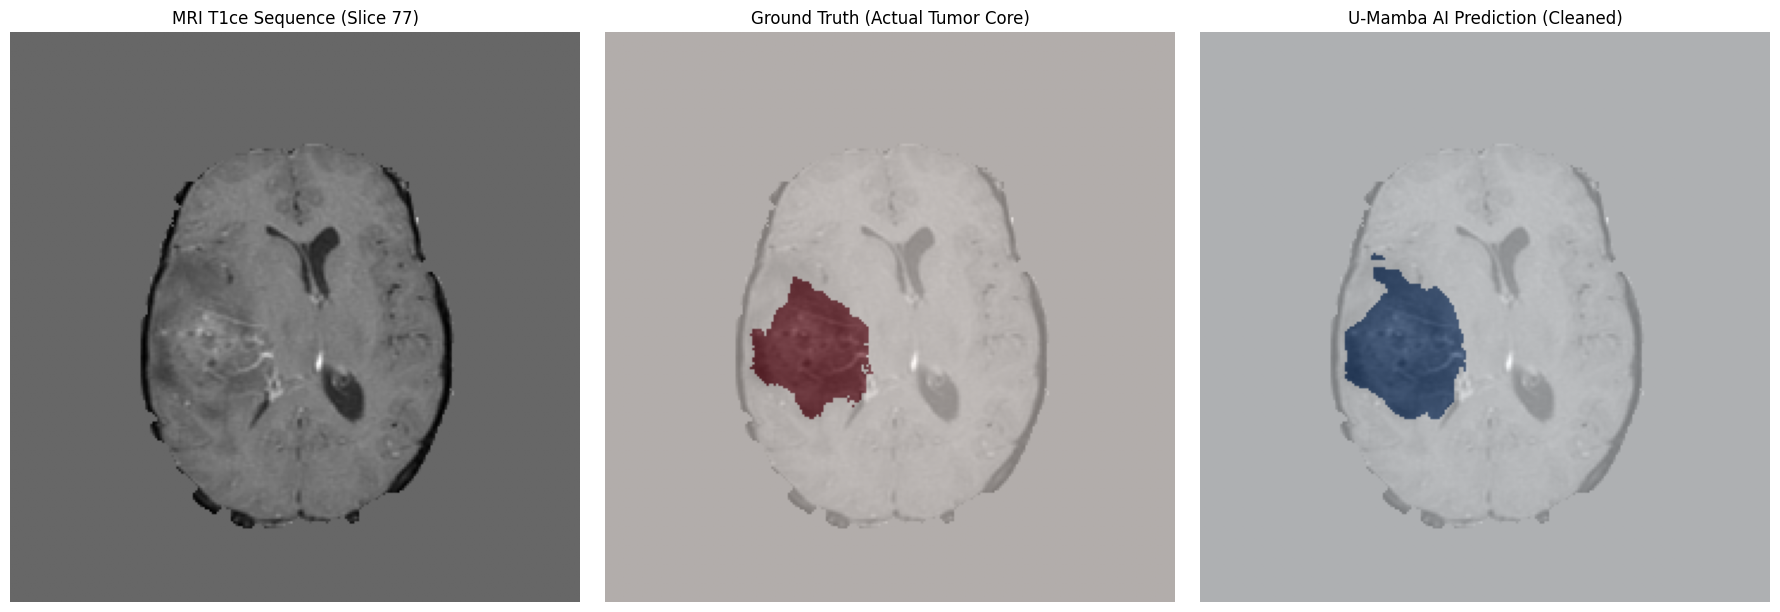

Step 6 Complete! Pipeline successfully finished.


In [4]:
import torch
import matplotlib.pyplot as plt
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, Spacingd, NormalizeIntensityd, EnsureTyped, MapTransform,
    KeepLargestConnectedComponent  # <--- IMPORT ADDED HERE
)
from monai.data import Dataset, DataLoader
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric

print("Starting Step 6: 3D Inference and Visualization...")

# 1. Define Validation Transforms 
# Notice there is NO cropping here; we process the entire full-resolution MRI volume
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result =[]
            # TC (Tumor Core)
            result.append(torch.logical_or(d[key] == 1, d[key] == 4))
            # WT (Whole Tumor)
            result.append(torch.logical_or(torch.logical_or(d[key] == 1, d[key] == 4), d[key] == 2))
            # ET (Enhancing Tumor)
            result.append(d[key] == 4)
            d[key] = torch.stack(result, axis=0).float()
        return d

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image"]),
    ConvertToMultiChannelBasedOnBratsClassesd(keys=["label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    EnsureTyped(keys=["image", "label"]),
])

# 2. Create Validation DataLoader
# We use batch_size=1 because full 3D MRI volumes are massive and use a lot of VRAM
val_ds = Dataset(data=val_files[:3], transform=val_transforms) 
val_loader = DataLoader(val_ds, batch_size=1, num_workers=2)

# 3. Load the best saved model weights from your Kaggle output directory
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("best_umamba_brats_model.pth"))
model.eval() 

# 4. Set up Clinical Evaluation Metric (Dice Only - No Compilation Required)
dice_metric = DiceMetric(include_background=False, reduction="mean")

# 5. Run Inference on a single patient
with torch.no_grad():
    for val_data in val_loader:
        val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
        
        # Sliding window sweeps the 96x96x96 patch across the full volume, overlapping by 50%
        val_outputs = sliding_window_inference(
            inputs=val_inputs, 
            roi_size=(96, 96, 96), 
            sw_batch_size=4, 
            predictor=model,
            overlap=0.5
        )
        
        # Apply sigmoid activation and threshold at 0.5
        val_outputs = (torch.sigmoid(val_outputs) > 0.5).float()
        
        # ---------------------------------------------------------
        # --- ADDED: Connected Component Post-Processing CODE   ---
        # ---------------------------------------------------------
        print("Applying Connected Component Post-Processing...")
        
        # Initialize the MONAI filter
        post_processing_filter = KeepLargestConnectedComponent(applied_labels=[1])
        
        # Create a clean tensor to hold the filtered results
        cleaned_outputs = torch.zeros_like(val_outputs)
        
        # Apply the filter independently to each clinical channel
        for c in range(val_outputs.shape[1]):
            # Extract the single channel 3D volume
            channel_data = val_outputs[0, c].unsqueeze(0)
            
            # Apply the filter and save it
            cleaned_channel = post_processing_filter(channel_data)
            cleaned_outputs[0, c] = cleaned_channel.squeeze(0)
            
        # Overwrite val_outputs with the cleaned version so metrics/plots use it!
        val_outputs = cleaned_outputs
        print("Phantom tumors removed!")
        # ---------------------------------------------------------

        # Compute metrics for this patient (now evaluated on the cleaned predictions!)
        dice_metric(y_pred=val_outputs, y=val_labels)
        
        # We only need one patient's data to visualize, so we break the loop here
        break

# Calculate and print final aggregated metrics
mean_dice = dice_metric.aggregate().item()
print(f"Evaluation on Test Patient -> Mean Dice Score: {mean_dice:.4f}")

# 6. Visualization (Extracting the exact middle Z-axis slice of the 3D volume)
# Tensors are shape (Batch, Channel, X, Y, Z). We select the first item in the batch.
img_vol = val_inputs.cpu().numpy() 
label_vol = val_labels.cpu().numpy() 
pred_vol = val_outputs.cpu().numpy() # This now safely contains the cleaned output

slice_idx = img_vol.shape[-1] // 2  # Calculate the middle depth slice

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title(f"MRI T1ce Sequence (Slice {slice_idx})")
# img_vol[0, 1] means -> Batch 0, Channel 1 (T1ce)
plt.imshow(img_vol[0, 1, :, :, slice_idx].T, cmap="gray", origin="lower")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Ground Truth (Actual Tumor Core)")
plt.imshow(img_vol[0, 1, :, :, slice_idx].T, cmap="gray", origin="lower")
# label_vol[0, 0] means -> Batch 0, Channel 0 (Tumor Core)
plt.imshow(label_vol[0, 0, :, :, slice_idx].T, cmap="Reds", alpha=0.5, origin="lower") 
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("U-Mamba AI Prediction (Cleaned)")
plt.imshow(img_vol[0, 1, :, :, slice_idx].T, cmap="gray", origin="lower")
# pred_vol[0, 0] means -> Batch 0, Channel 0 (Predicted Tumor Core)
plt.imshow(pred_vol[0, 0, :, :, slice_idx].T, cmap="Blues", alpha=0.5, origin="lower") 
plt.axis('off')

plt.tight_layout()
plt.show()

print("Step 6 Complete! Pipeline successfully finished.")

Starting Step 6: Full 3D Inference and Visualization...
Checking 74 patients for missing files...


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Skipped corrupted/missing patient data.
Cleaned dataset size: 73 valid patients.


/tmp/ipykernel_57/1967973159.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_umamba_brats_model.pth"))


Processing patient 1 of 73...
Processing patient 2 of 73...
Processing patient 3 of 73...
Processing patient 4 of 73...
Processing patient 5 of 73...
Processing patient 6 of 73...
Processing patient 7 of 73...
Processing patient 8 of 73...
Processing patient 9 of 73...
Processing patient 10 of 73...
Processing patient 11 of 73...
Processing patient 12 of 73...
Processing patient 13 of 73...
Processing patient 14 of 73...
Processing patient 15 of 73...
Processing patient 16 of 73...
Processing patient 17 of 73...
Processing patient 18 of 73...
Processing patient 19 of 73...
Processing patient 20 of 73...
Processing patient 21 of 73...
Processing patient 22 of 73...
Processing patient 23 of 73...
Processing patient 24 of 73...
Processing patient 25 of 73...
Processing patient 26 of 73...
Processing patient 27 of 73...
Processing patient 28 of 73...
Processing patient 29 of 73...
Processing patient 30 of 73...
Processing patient 31 of 73...
Processing patient 32 of 73...
Processing patien

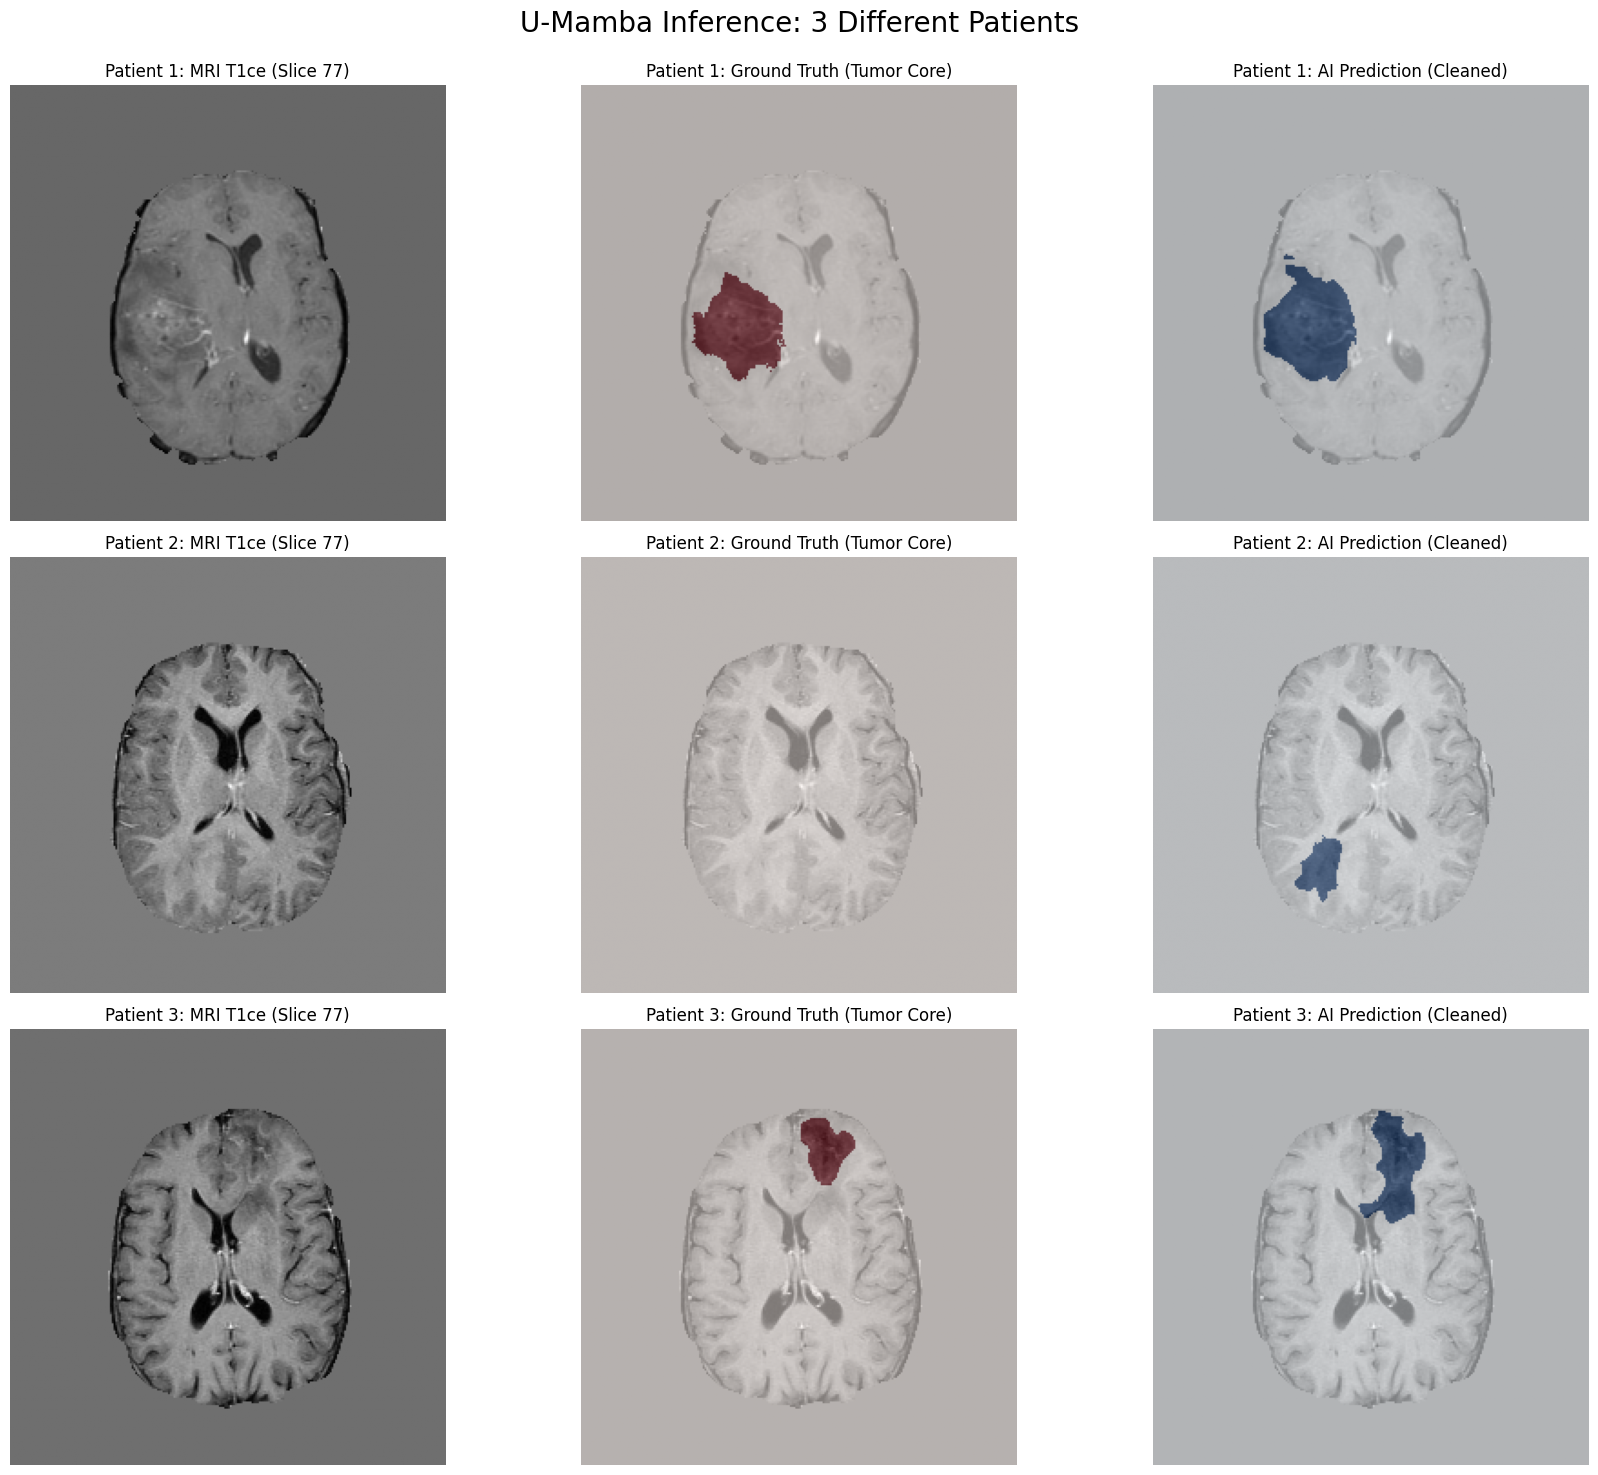

Step 6 Complete! Pipeline successfully finished.


In [5]:
import os
import torch
import matplotlib.pyplot as plt
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, Spacingd, NormalizeIntensityd, EnsureTyped, MapTransform,
    KeepLargestConnectedComponent
)
from monai.data import Dataset, DataLoader
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric

print("Starting Step 6: Full 3D Inference and Visualization...")

# 1. Define Validation Transforms 
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result =[]
            # TC (Tumor Core)
            result.append(torch.logical_or(d[key] == 1, d[key] == 4))
            # WT (Whole Tumor)
            result.append(torch.logical_or(torch.logical_or(d[key] == 1, d[key] == 4), d[key] == 2))
            # ET (Enhancing Tumor)
            result.append(d[key] == 4)
            d[key] = torch.stack(result, axis=0).float()
        return d

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image"]),
    ConvertToMultiChannelBasedOnBratsClassesd(keys=["label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    EnsureTyped(keys=["image", "label"]),
])

# ---------------------------------------------------------
# --- ADDED: Filter out corrupted/missing BraTS files   ---
# ---------------------------------------------------------
print(f"Checking {len(val_files)} patients for missing files...")
clean_val_files =[]

for item in val_files:
    is_valid = True
    
    # Check if the label file exists
    label_path = item["label"]
    if isinstance(label_path, list):
        if not all(os.path.exists(p) for p in label_path): is_valid = False
    else:
        if not os.path.exists(label_path): is_valid = False

    # Check if the image files exist
    img_paths = item["image"]
    if isinstance(img_paths, list):
        if not all(os.path.exists(p) for p in img_paths): is_valid = False
    else:
        if not os.path.exists(img_paths): is_valid = False
        
    if is_valid:
        clean_val_files.append(item)
    else:
        print(f"Skipped corrupted/missing patient data.")

print(f"Cleaned dataset size: {len(clean_val_files)} valid patients.")
# ---------------------------------------------------------

# 2. Create Validation DataLoader using the CLEANED files
val_ds = Dataset(data=clean_val_files, transform=val_transforms) 
val_loader = DataLoader(val_ds, batch_size=1, num_workers=2)

# 3. Load the best saved model weights from your Kaggle output directory
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("best_umamba_brats_model.pth"))
model.eval() 

# 4. Set up Clinical Evaluation Metric (Dice Only)
dice_metric = DiceMetric(include_background=False, reduction="mean")
post_processing_filter = KeepLargestConnectedComponent(applied_labels=[1])

# We will store the arrays of the first 3 patients here for visualization later
vis_data =[]

# 5. Run Inference on the ENTIRE clean test dataset
with torch.no_grad():
    for i, val_data in enumerate(val_loader):
        print(f"Processing patient {i+1} of {len(val_loader)}...")
        
        val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)
        
        # Sliding window sweeps the 96x96x96 patch across the full volume
        val_outputs = sliding_window_inference(
            inputs=val_inputs, 
            roi_size=(96, 96, 96), 
            sw_batch_size=4, 
            predictor=model,
            overlap=0.5
        )
        
        # Apply sigmoid activation and threshold at 0.5
        val_outputs = (torch.sigmoid(val_outputs) > 0.5).float()
        
        # Apply Connected Component Post-Processing
        cleaned_outputs = torch.zeros_like(val_outputs)
        for c in range(val_outputs.shape[1]):
            channel_data = val_outputs[0, c].unsqueeze(0)
            cleaned_channel = post_processing_filter(channel_data)
            cleaned_outputs[0, c] = cleaned_channel.squeeze(0)
            
        val_outputs = cleaned_outputs

        # Compute metrics for this patient (accumulates continuously)
        dice_metric(y_pred=val_outputs, y=val_labels)
        
        # Save ONLY the first 3 patients to memory for matplotlib visualization
        if i < 3:
            vis_data.append({
                "img": val_inputs.cpu().numpy(),
                "label": val_labels.cpu().numpy(),
                "pred": val_outputs.cpu().numpy()
            })

# Calculate and print final aggregated metrics across the WHOLE dataset
mean_dice = dice_metric.aggregate().item()
print(f"\nEvaluation on Entire Test Set -> Mean Dice Score: {mean_dice:.4f}")

# 6. Visualization (Plotting the 3 saved patients in a 3x3 grid)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
fig.suptitle("U-Mamba Inference: 3 Different Patients", fontsize=20, y=0.98)

for idx, data in enumerate(vis_data):
    img_vol = data["img"]
    label_vol = data["label"]
    pred_vol = data["pred"]
    
    # Calculate the middle depth slice for this specific patient
    slice_idx = img_vol.shape[-1] // 2  

    # T1ce Sequence (Left Column)
    axes[idx, 0].set_title(f"Patient {idx+1}: MRI T1ce (Slice {slice_idx})")
    axes[idx, 0].imshow(img_vol[0, 1, :, :, slice_idx].T, cmap="gray", origin="lower")
    axes[idx, 0].axis('off')

    # Ground Truth (Middle Column)
    axes[idx, 1].set_title(f"Patient {idx+1}: Ground Truth (Tumor Core)")
    axes[idx, 1].imshow(img_vol[0, 1, :, :, slice_idx].T, cmap="gray", origin="lower")
    axes[idx, 1].imshow(label_vol[0, 0, :, :, slice_idx].T, cmap="Reds", alpha=0.5, origin="lower") 
    axes[idx, 1].axis('off')

    # AI Prediction (Right Column)
    axes[idx, 2].set_title(f"Patient {idx+1}: AI Prediction (Cleaned)")
    axes[idx, 2].imshow(img_vol[0, 1, :, :, slice_idx].T, cmap="gray", origin="lower")
    axes[idx, 2].imshow(pred_vol[0, 0, :, :, slice_idx].T, cmap="Blues", alpha=0.5, origin="lower") 
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.93) # Make room for the main title
plt.show()

print("Step 6 Complete! Pipeline successfully finished.")